In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('apple_products (1).csv')

In [4]:
df.head()

,Product Name,Product URL,Brand,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Upc,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",https://www.flipkart.com/apple-iphone-8-plus-g...,Apple,49900,49900,0,3431,356,MOBEXRGV7EHHTGUH,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVAC6TJT4F,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVGETABXWZ,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-silver...,Apple,77000,77000,0,11202,794,MOBEXRGVMZWUHCBA,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",https://www.flipkart.com/apple-iphone-8-gold-2...,Apple,77000,77000,0,11202,794,MOBEXRGVPK7PFEJZ,4.5,2 GB


In [5]:
cols = ['Product URL', 'Brand', 'Upc']
df.drop(columns=cols, inplace =True)

In [6]:
df.head()

,Product Name,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",49900,49900,0,3431,356,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",84900,84900,0,3431,356,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",84900,84900,0,3431,356,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",77000,77000,0,11202,794,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",77000,77000,0,11202,794,4.5,2 GB


In [7]:
# Extracting Color and Rom from Product Name column using regex
df[['Color', 'Rom']] = df['Product Name'].str.extract(r'\(([^,]+),\s*([^)]+)\)')
df['Product Name'] = df['Product Name'].str.replace(r'\s*\(.*\)', '', regex=True)

In [8]:
df

,Product Name,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating,Ram,Color,Rom
0,APPLE iPhone 8 Plus,49900,49900,0,3431,356,4.6,2 GB,Gold,64 GB
1,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Space Grey,256 GB
2,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Silver,256 GB
3,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Silver,256 GB
4,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Gold,256 GB
...,...,...,...,...,...,...,...,...,...,...
57,APPLE iPhone SE,29999,39900,24,95909,8161,4.5,4 GB,Black,64 GB
58,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Purple,64 GB
59,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,White,64 GB
60,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Black,64 GB


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Name         62 non-null     object 
 1   Sale Price           62 non-null     int64  
 2   Mrp                  62 non-null     int64  
 3   Discount Percentage  62 non-null     int64  
 4   Number Of Ratings    62 non-null     int64  
 5   Number Of Reviews    62 non-null     int64  
 6   Star Rating          62 non-null     float64
 7   Ram                  62 non-null     object 
 8   Color                62 non-null     object 
 9   Rom                  62 non-null     object 
dtypes: float64(1), int64(5), object(4)
memory usage: 5.0+ KB


In [10]:
df[df.duplicated()].shape

(0, 10)

In [11]:
df.describe()

,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,80073.887097,88058.064516,9.951613,22420.403226,1861.677419,4.575806
std,34310.446132,34728.825597,7.608079,33768.589550,2855.883830,0.059190
min,29999.000000,39900.000000,0.000000,542.000000,42.000000,4.500000
25%,49900.000000,54900.000000,6.000000,740.000000,64.000000,4.500000
50%,75900.000000,79900.000000,10.000000,2101.000000,180.000000,4.600000
75%,117100.000000,120950.000000,14.000000,43470.000000,3331.000000,4.600000
max,140900.000000,149900.000000,29.000000,95909.000000,8161.000000,4.700000


In [12]:
df['Number Of Ratings'].value_counts()

Number Of Ratings
580      8
3431     5
1078     5
2101     5
43470    5
95909    4
79512    4
740      4
545      4
7088     3
11202    3
730      2
2092     2
43707    2
95807    2
79582    1
7081     1
1454     1
542      1
Name: count, dtype: int64

In [13]:
df['Product Name'] = df['Product Name'].str.replace('Apple', 'APPLE')

#  Top 10 Highest-rated iPhone Models 

In [14]:
top_10_unique = df.sort_values(by=['Star Rating', 'Number Of Ratings'], ascending=False).drop_duplicates(subset=['Product Name']).head(10)

top_10_unique[['Product Name', 'Star Rating', 'Number Of Ratings']]

,Product Name,Star Rating,Number Of Ratings
14,APPLE iPhone 11 Pro Max,4.7,1078
11,APPLE iPhone XR,4.6,79582
50,APPLE iPhone 11,4.6,43707
18,APPLE iPhone 11 Pro,4.6,7088
0,APPLE iPhone 8 Plus,4.6,3431
29,APPLE iPhone 12,4.6,2101
8,APPLE iPhone XS Max,4.6,1454
25,APPLE iPhone 12 Pro Max,4.6,580
23,APPLE iPhone SE,4.5,95909
3,APPLE iPhone 8,4.5,11202


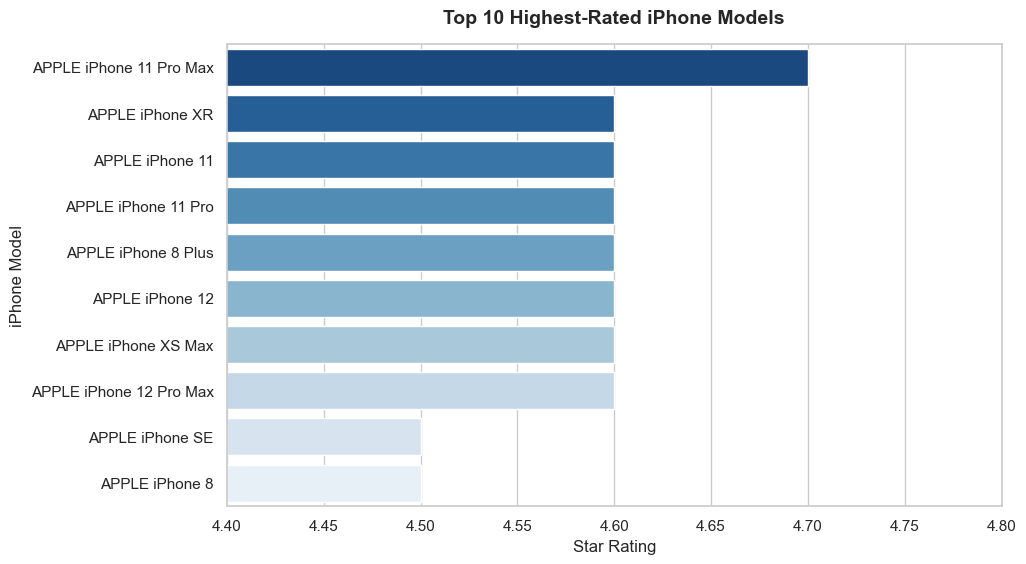

In [15]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x='Star Rating', y='Product Name', data=top_10_unique, hue='Product Name', legend = False, palette='Blues_r')

plt.title('Top 10 Highest-Rated iPhone Models', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('iPhone Model', fontsize=12)

plt.xlim(4.4, 4.8)
plt.show()

# The iPhone 11 Pro Max is the highest rated iPhone with 4.7 Star Ratings and 1078 Number of Ratings.

In [16]:
df

,Product Name,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating,Ram,Color,Rom
0,APPLE iPhone 8 Plus,49900,49900,0,3431,356,4.6,2 GB,Gold,64 GB
1,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Space Grey,256 GB
2,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Silver,256 GB
3,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Silver,256 GB
4,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Gold,256 GB
...,...,...,...,...,...,...,...,...,...,...
57,APPLE iPhone SE,29999,39900,24,95909,8161,4.5,4 GB,Black,64 GB
58,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Purple,64 GB
59,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,White,64 GB
60,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Black,64 GB


In [17]:
top_reviewed = df.sort_values(by=['Number Of Reviews'], ascending=False).drop_duplicates(subset=['Product Name'])[['Product Name', 'Number Of Reviews']].head(10)

In [18]:
top_reviewed

,Product Name,Number Of Reviews
23,APPLE iPhone SE,8161
11,APPLE iPhone XR,6804
51,APPLE iPhone 11,3357
7,APPLE iPhone 8,794
18,APPLE iPhone 11 Pro,523
1,APPLE iPhone 8 Plus,356
44,APPLE iPhone 12,180
8,APPLE iPhone XS Max,149
17,APPLE iPhone 11 Pro Max,101
28,APPLE iPhone 12 Mini,64


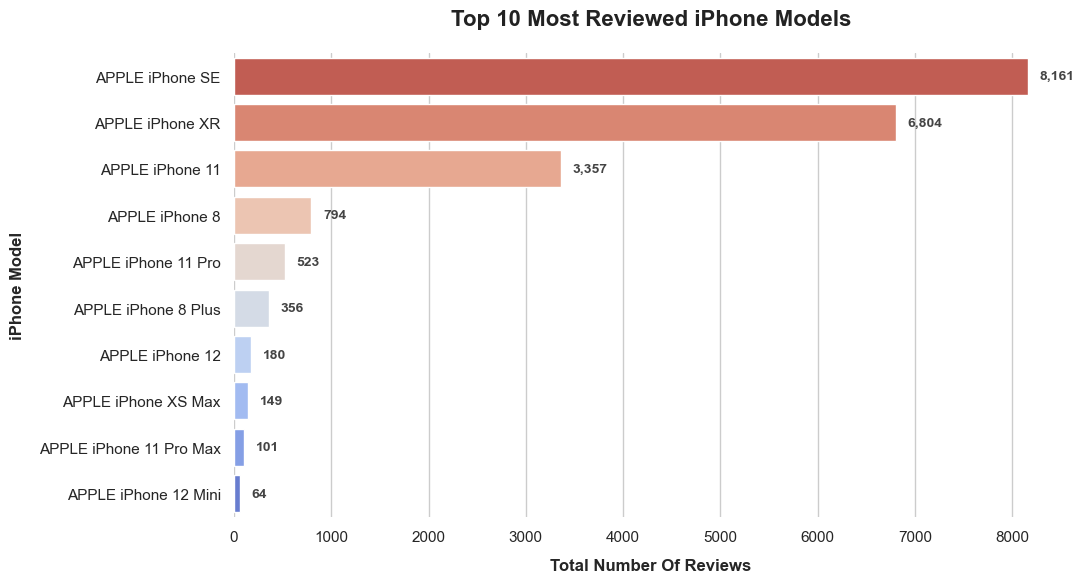

In [19]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))
bar_plot = sns.barplot(
    x = 'Number Of Reviews',
    y = 'Product Name',
    data = top_reviewed,
    palette='coolwarm_r',
    hue='Product Name',
    legend=False,
    ax = ax)

for p in bar_plot.patches:
    width = p.get_width()
    ax.text(
    width + 120,
    p.get_y() + p.get_height() / 2,
    f'{int(width):,}',
    va='center',
    fontsize=10,
    fontweight='semibold',
    color='#444444')

ax.set_title('Top 10 Most Reviewed iPhone Models', fontsize=16, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Total Number Of Reviews', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('iPhone Model', fontsize=12, fontweight='semibold', labelpad=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()

In [20]:
df

,Product Name,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating,Ram,Color,Rom
0,APPLE iPhone 8 Plus,49900,49900,0,3431,356,4.6,2 GB,Gold,64 GB
1,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Space Grey,256 GB
2,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Silver,256 GB
3,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Silver,256 GB
4,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Gold,256 GB
...,...,...,...,...,...,...,...,...,...,...
57,APPLE iPhone SE,29999,39900,24,95909,8161,4.5,4 GB,Black,64 GB
58,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Purple,64 GB
59,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,White,64 GB
60,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Black,64 GB


# Doing Linear Regression to find correlation between Sale Price and Number Of Ratings..

In [21]:
correlation = df['Sale Price'].corr(df['Number Of Ratings'])
print("Correlation Coefficient", correlation)

Correlation Coefficient -0.7015259181182026


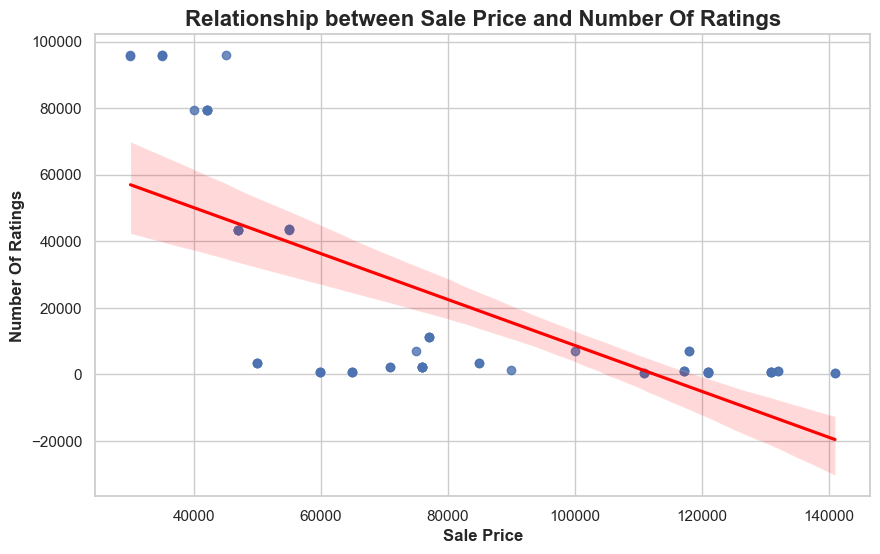

In [22]:
sns.set_theme(style="whitegrid")
fig =plt.subplots(figsize=(10, 6))

sns.regplot(
    x='Sale Price',
    y = 'Number Of Ratings',
    data=df,
    line_kws={'color':'red'})
plt.xlabel("Sale Price", fontsize=12, fontweight='semibold' )
plt.ylabel("Number Of Ratings", fontsize=12, fontweight='semibold')
plt.title("Relationship between Sale Price and Number Of Ratings", fontsize=16, fontweight='bold')

plt.show()

# Conclusion:
- There's a -0.70 Correlation Coefficient between Sale Price and Number Of Ratings,
which stats that No. Of Ratings increases when the Sale price is low and vise verca.

In [23]:
df

,Product Name,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating,Ram,Color,Rom
0,APPLE iPhone 8 Plus,49900,49900,0,3431,356,4.6,2 GB,Gold,64 GB
1,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Space Grey,256 GB
2,APPLE iPhone 8 Plus,84900,84900,0,3431,356,4.6,2 GB,Silver,256 GB
3,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Silver,256 GB
4,APPLE iPhone 8,77000,77000,0,11202,794,4.5,2 GB,Gold,256 GB
...,...,...,...,...,...,...,...,...,...,...
57,APPLE iPhone SE,29999,39900,24,95909,8161,4.5,4 GB,Black,64 GB
58,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Purple,64 GB
59,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,White,64 GB
60,APPLE iPhone 11,46999,54900,14,43470,3331,4.6,4 GB,Black,64 GB


# Doing Linear reggration to find Correlationship between Discount percentage and Number of Ratings

In [24]:
correlation= df['Discount Percentage'].corr(df['Number Of Ratings'])
print('Correlation Coefficient:', correlation)

Correlation Coefficient: 0.6848270553540624


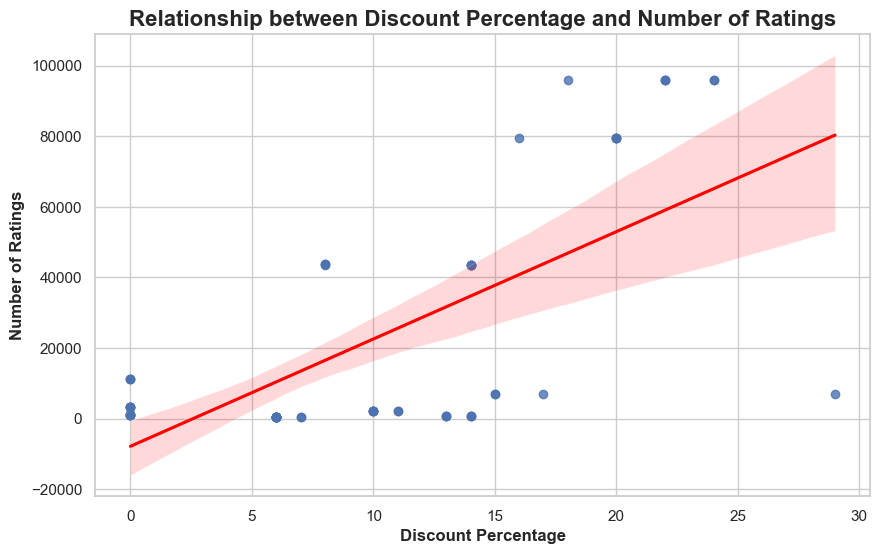

In [25]:
sns.set_theme(style="whitegrid")
fig= plt.subplots(figsize=(10, 6))

sns.regplot(
    x='Discount Percentage',
    y='Number Of Ratings',
    data = df,
    line_kws={'color':'red'})

plt.title('Relationship between Discount Percentage and Number of Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Discount Percentage', fontsize=12, fontweight='semibold')
plt.ylabel('Number of Ratings', fontsize=12, fontweight='semibold')
plt.show()

# Least expensive and Most expensive iPhone with their specifications.

In [26]:
cheapest_iphone = df.loc[df['Sale Price'].idxmin()]
expensive_iphone = df.loc[df['Sale Price'].idxmax()]

spec_columns = ['Product Name', 'Sale Price', 'Mrp', 'Discount Percentage', 'Number Of Ratings', 'Star Rating', 'Ram', 'Rom', 'Color']

print("LEAST EXPENSIVE IPHONE SPECIFICATIONS")
print(cheapest_iphone[spec_columns].to_string())

print("\n" + "MOST EXPENSIVE IPHONE SPECIFICATIONS")
print(expensive_iphone[spec_columns].to_string())

LEAST EXPENSIVE IPHONE SPECIFICATIONS
Product Name           APPLE iPhone SE
Sale Price                       29999
Mrp                              39900
Discount Percentage                 24
Number Of Ratings                95807
Star Rating                        4.5
Ram                               2 GB
Rom                              64 GB
Color                            White

MOST EXPENSIVE IPHONE SPECIFICATIONS
Product Name           APPLE iPhone 12 Pro
Sale Price                          140900
Mrp                                 149900
Discount Percentage                      6
Number Of Ratings                      542
Star Rating                            4.5
Ram                                   4 GB
Rom                                 512 GB
Color                               Silver


##  Conclusion

This analysis explored iPhone product listings to understand pricing, 
customer ratings, discount patterns, and product specifications.


### Key Takeaways

**1. iPhone 11 Pro Max is the Most Trusted Model**
With a star rating of 4.7 and 1,078 ratings, the iPhone 11 Pro Max 
stands out as the highest-rated model — reflecting strong customer 
satisfaction despite being a premium-priced device.

**2. Lower Prices Drive More Customer Engagement**
The correlation coefficient of **-0.70** between Sale Price and Number 
of Ratings is a strong negative relationship. This tells us that 
budget-friendly iPhones attract significantly more buyers and reviewers 
— which makes sense in a price-sensitive market like India where 
affordable models see higher sales volumes.

**3. Discounts Positively Influence Buying Behaviour**
A positive correlation between Discount Percentage and Number of Ratings 
suggests that promotional pricing encourages more purchases, and 
consequently more customer reviews. Brands and retailers can leverage 
discounting as a strategy to boost visibility and social proof.

**4. Wide Price Range Across Models**
The dataset reveals a significant gap between the cheapest and most 
expensive iPhones — highlighting Apple's strategy of maintaining both 
entry-level and ultra-premium segments to serve a wide customer base.


### Final Thought
The data clearly shows that **price is the most influential factor** 
in determining how many customers engage with a product through ratings 
and reviews. For a market like India, Apple's mid-range and older models 
tend to generate the most community engagement, while flagship models 
appeal to a smaller but loyal premium customer segment.
